# CAPM Analysis of Selected Indian Equities

**Capital Asset Pricing Model (CAPM) analysis using NIFTY 50 and four NSE-listed stocks**

This project estimates **Beta**, **CAPM expected return**, and the difference between each stock's annualized average return and its CAPM-implied return.

### Securities
- HDFC Bank (`HDFCBANK.NS`)
- TCS (`TCS.NS`)
- Reliance Industries (`RELIANCE.NS`)
- Infosys (`INFY.NS`)
- Market proxy: NIFTY 50 (`^NSEI`)

**Sample period:** 2 January 2020 – 31 December 2024  
**Frequency:** Daily returns  
**Risk-free rate:** 7% per year  
**Trading days used for annualization:** 252

> This is an educational analysis, not investment advice.


## 1. Imports and configuration

The analysis uses `yfinance` to retrieve historical adjusted closing prices and `pandas`/`numpy` for data handling and calculations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

TICKERS = ["HDFCBANK.NS", "TCS.NS", "RELIANCE.NS", "INFY.NS"]
MARKET = "^NSEI"

START_DATE = "2020-01-01"
END_DATE = "2025-01-01"

RISK_FREE_RATE = 0.07
TRADING_DAYS = 252


## 2. Download historical price data

Adjusted closing prices are used so that the return series accounts for applicable corporate actions reflected in the adjusted price series.

The market benchmark is the NIFTY 50 index.


In [2]:
symbols = TICKERS + [MARKET]

prices = yf.download(
    symbols,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna(how="all").sort_index()

prices.head()


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2020-01-01,595.677185,619.740417,672.216125,1831.109741,12182.500000
2020-01-02,599.474121,617.932129,683.660217,1822.703857,12282.200195
2020-01-03,590.925232,627.436096,684.484009,1859.029297,12226.650391
2020-01-06,578.136780,621.422363,668.609253,1858.860352,11993.049805
2020-01-07,587.291260,612.212769,678.895630,1863.421997,12052.950195


## 3. Calculate daily returns

CAPM Beta is estimated from daily stock and market returns.




In [3]:
returns = prices.pct_change(fill_method=None).dropna()

returns.head()


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2020-01-02,0.006374,-0.002918,0.017024,-0.004591,0.008184
2020-01-03,-0.014261,0.015380,0.001205,0.019929,-0.004523
2020-01-06,-0.021641,-0.009585,-0.023192,-0.000091,-0.019106
2020-01-07,0.015834,-0.014820,0.015385,0.002454,0.004995
2020-01-08,-0.002618,-0.013326,-0.007510,0.022395,-0.002290


## 4. CAPM calculation

The CAPM expected return is:


E(R_i) = R_f + beta_i [E(R_m) - R_f]


where:

- \(R_f\) = annual risk-free rate
- \(E(R_m)\) = annualized average market return
- \(beta_i\) = covariance of stock returns with market returns divided by market return variance

For consistency with the original analysis, annual returns are estimated by multiplying the mean daily return by 252.


In [4]:
def capm(stock_returns, market_returns, risk_free_rate, trading_days=252):
    """Calculate CAPM beta and CAPM-implied annual return."""
    covariance = np.cov(stock_returns, market_returns, ddof=0)[0, 1]
    market_variance = np.var(market_returns, ddof=0)

    beta = covariance / market_variance
    market_return = np.mean(market_returns) * trading_days

    capm_return = risk_free_rate + beta * (market_return - risk_free_rate)

    return beta, capm_return


## 5. Estimate Beta and compare returns

The project's comparison metric is:

Return Difference =
Annualized Average Return - CAPM Expected Return


A positive value means the stock's annualized average return was above its CAPM-implied return over this sample. 


In [5]:
market_returns = returns[MARKET]

results = []

for ticker in TICKERS:
    beta, capm_return = capm(
        returns[ticker],
        market_returns,
        RISK_FREE_RATE,
        TRADING_DAYS
    )

    annualized_average_return = returns[ticker].mean() * TRADING_DAYS
    return_difference = annualized_average_return - capm_return

    results.append({
        "Stock": ticker,
        "Beta": beta,
        "CAPM Expected Return": capm_return,
        "Annualized Average Return": annualized_average_return,
        "Return Difference": return_difference
    })

results_df = pd.DataFrame(results)

results_display = results_df.copy()
for col in ["CAPM Expected Return", "Annualized Average Return", "Return Difference"]:
    results_display[col] = results_display[col] * 100

results_display.round(2)


,Stock,Beta,CAPM Expected Return,Annualized Average Return,Return Difference
0,HDFCBANK.NS,1.08,15.82,10.50,-5.33
1,TCS.NS,0.75,13.11,17.90,4.78
2,RELIANCE.NS,1.11,16.06,16.36,0.30
3,INFY.NS,0.89,14.27,25.51,11.24


## 6. Security Market Line

The Security Market Line (SML) represents the CAPM relationship between systematic risk (Beta) and expected return.

For this chart, the same **7% annual risk-free rate** and annualized market return used above are applied.


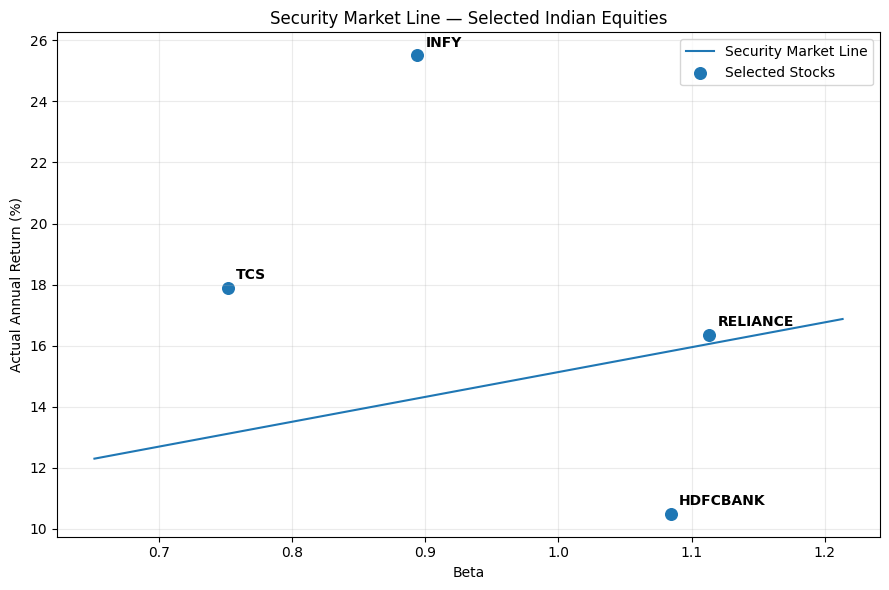

In [10]:
market_return_annual = market_returns.mean() * TRADING_DAYS

beta_range = np.linspace(
    results_df["Beta"].min() - 0.1,
    results_df["Beta"].max() + 0.1,
    100
)

sml = RISK_FREE_RATE + beta_range * (market_return_annual - RISK_FREE_RATE)

plt.figure(figsize=(9, 6))
plt.plot(
    beta_range,
    sml * 100,
    label="Security Market Line"
)

plt.scatter(
    results_df["Beta"],
    results_df["Annualized Average Return"] * 100,
    s=70,
    label="Selected Stocks"
)

for _, row in results_df.iterrows():
    plt.annotate(
        row["Stock"].replace(".NS", ""),
        (row["Beta"], row["Annualized Average Return"] * 100),
        xytext=(6, 6),
        textcoords="offset points",
        fontweight = "bold"
    )

plt.xlabel("Beta")
plt.ylabel("Actual Annual Return (%)")
plt.title("Security Market Line — Selected Indian Equities")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Key observations

Using the original project's sample and assumptions:

- **HDFC Bank:** Beta ≈ 1.09; annualized average return ≈ 11.22%; CAPM expected return ≈ 16.08%.
- **TCS:** Beta ≈ 0.75; annualized average return ≈ 17.94%; CAPM expected return ≈ 13.28%.
- **Reliance Industries:** Beta ≈ 1.11; annualized average return ≈ 16.30%; CAPM expected return ≈ 16.31%.
- **Infosys:** Beta ≈ 0.89; annualized average return ≈ 25.46%; CAPM expected return ≈ 14.47%.

The results illustrate that higher Beta does not mechanically imply higher realized returns. CAPM provides a required/expected return based on systematic market risk; realized returns can differ substantially because of firm-specific and other factors.


## 8. Limitations and possible extensions

This is a first-pass CAPM study rather than a full empirical asset-pricing test.

Potential extensions:

1. Estimate Beta using a rolling window rather than the full sample.
2. Run a formal time-series regression of stock excess returns on market excess returns.
3. Test statistical significance of the regression coefficients.
4. Compare different risk-free-rate assumptions.
5. Add more stocks and sectors.
6. Compare CAPM with multi-factor models such as Fama-French.
7. Examine whether results are robust across different sub-periods.

These extensions would turn the project from a basic CAPM implementation into a more rigorous quantitative research exercise.


## References / data source

- Historical market data: Yahoo Finance via `yfinance`
- Market proxy: NIFTY 50
- CAPM framework: Sharpe / Lintner capital asset pricing framework

**Disclaimer:** This project is for educational and portfolio-research purposes only and does not constitute investment advice.
